# Configuration

In [1]:
import os 
import pickle

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

from scipy.special import expit
from scipy.stats import skew, kurtosis
from sklearn.linear_model import LogisticRegression, Lasso 
from sklearn.model_selection import cross_val_score

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from core.dgp import DataGenerationProcess, Targeting
from core.targeting import *
from core.variables import *
from core.utils import * 

# DGP

In [5]:
dgp_params = {
    'base_effect_vars': [PointMass(1 + i * 0.05) for i in range(2)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

# dgp_params = {
#     'base_effect_vars': [PointMass(0.1), PointMass(0.11)], 
#     'cust_feat_var': Uniform(0, 1), 
#     'char_func': lambda x: x**2 + x, 
#     'response_type': 'bernoulli', 
#     'dgp_seed': 0
# }

# instantiate the DGP
dgp = Targeting(**dgp_params)

In [6]:
# sample 
cust_features, treatments, outcomes = dgp.sample(500)
oos_cust_features = dgp.sample_individuals(5000)

In [7]:
true_te_arr, _ = dgp.predict_incremental_effect(cust_features)

# Estimation

In [8]:
cfdml = CausalForestDML(
    n_treatments=2, 
    model_t=LogisticRegression(C=0.01), 
    # model_y=LogisticRegression(C=0.01), 
    model_y=Lasso(alpha=0.01), 
    n_estimators=100, 
    max_depth=10, 
    n_jobs=-1, 
    # discrete_outcome=True, 
    discrete_treatment=True
).fit(X=cust_features, Y=outcomes, T=treatments)

emp_targ_te_arr, emp_targ_var_arr = cfdml.predict_incremental_effect(oos_cust_features)

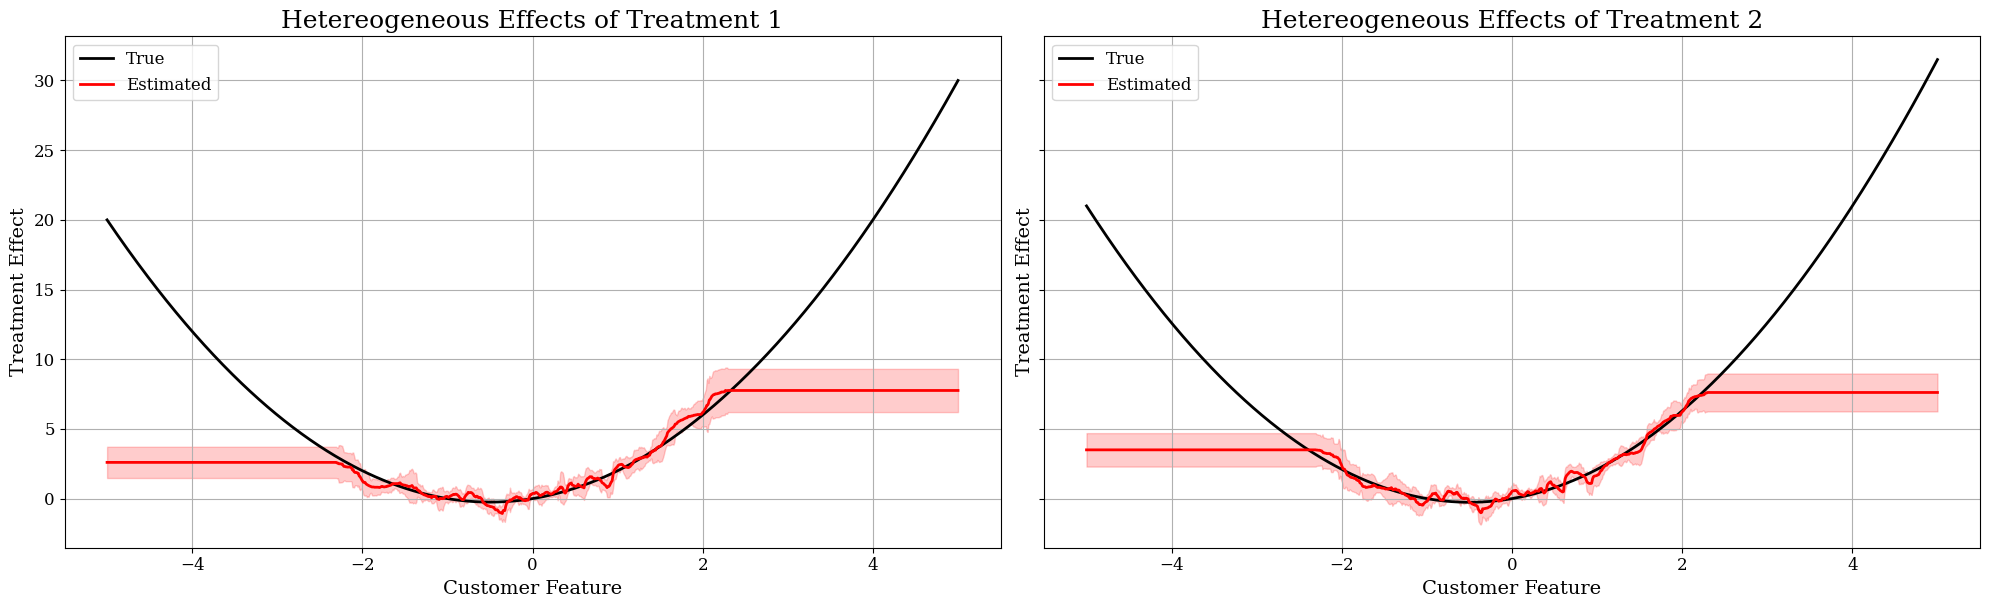

In [9]:
plot_hte(dgp, model=cfdml, ci=True, x_lb=-5, x_ub=5)

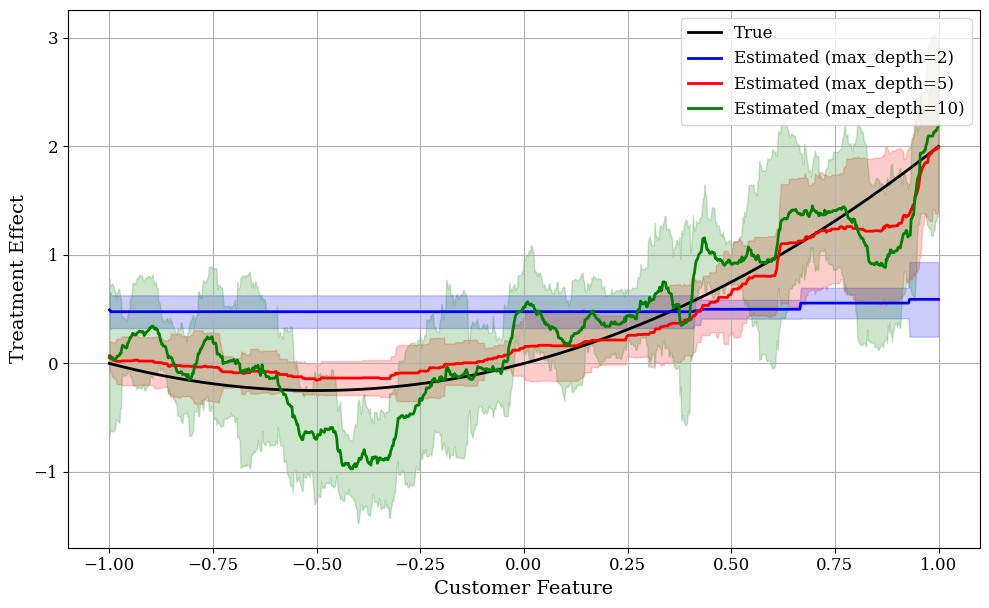

In [21]:
depths = [2, 5, 10]
models = {}

for depth in depths:
    models[depth] = CausalForestDML(
        n_treatments=2, 
        model_t=LogisticRegression(C=0.01),
        model_y=Lasso(alpha=0.01), 
        n_estimators=100, 
        max_depth=depth, 
        n_jobs=-1,
        discrete_treatment=True
    ).fit(X=cust_features, Y=outcomes, T=treatments)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

x = np.linspace(-1, 1, 1000).reshape(-1, 1)

# true HTE
true_inc_te_arr, _ = dgp.predict_incremental_effect(x)
ax.plot(
    x, true_inc_te_arr[:, 0], label='True', color='black', linewidth=2
)

colors = {'2': 'blue', '5': 'red', '10': 'green'}

# plot estimated HTE for each depth
for depth in depths:
    est_inc_te_arr, _ = models[depth].predict_incremental_effect(x)
    ax.plot(
        x, est_inc_te_arr[:, 0],
        label=f'Estimated (max_depth={depth})',
        color=colors[str(depth)], linewidth=2
    )
    ci_lb, ci_ub = models[depth].predict_incremental_effect_interval(x)
    ax.fill_between(
        x.flatten(),
        ci_lb[:, 0],
        ci_ub[:, 0],
        alpha=0.2,
        color=colors[str(depth)]
    )

ax.set_xlabel('Customer Feature', fontsize=axis_label_size)
ax.set_ylabel('Treatment Effect', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/cf_depth_compare.jpg')
plt.show()

## Visualizing Tree

[Text(0.5972222222222222, 0.9, 'x[0] <= 1.287\nmse = 2.546\nsamples = 338\nvalue = [[0.721]\n[0.999]]'),
 Text(0.3055555555555556, 0.7, 'x[0] <= -1.287\nmse = 1.932\nsamples = 305\nvalue = [[0.383]\n[0.482]]'),
 Text(0.16666666666666666, 0.5, 'x[0] <= -1.538\nmse = 3.067\nsamples = 32\nvalue = [[1.99]\n[1.473]]'),
 Text(0.1111111111111111, 0.3, 'x[0] <= -2.024\nmse = 2.991\nsamples = 22\nvalue = [[2.915]\n[2.012]]'),
 Text(0.05555555555555555, 0.1, '\n  (...)  \n'),
 Text(0.16666666666666666, 0.1, '\n  (...)  \n'),
 Text(0.2222222222222222, 0.3, 'mse = 0.496\nsamples = 10\nvalue = [[0.522]\n[-0.058]]'),
 Text(0.4444444444444444, 0.5, 'x[0] <= 0.028\nmse = 1.116\nsamples = 273\nvalue = [[0.329]\n[0.296]]'),
 Text(0.3333333333333333, 0.3, 'x[0] <= -0.678\nmse = 0.884\nsamples = 153\nvalue = [[-0.13]\n[-0.375]]'),
 Text(0.2777777777777778, 0.1, '\n  (...)  \n'),
 Text(0.3888888888888889, 0.1, '\n  (...)  \n'),
 Text(0.5555555555555556, 0.3, 'x[0] <= 0.14\nmse = 1.205\nsamples = 120\nvalue

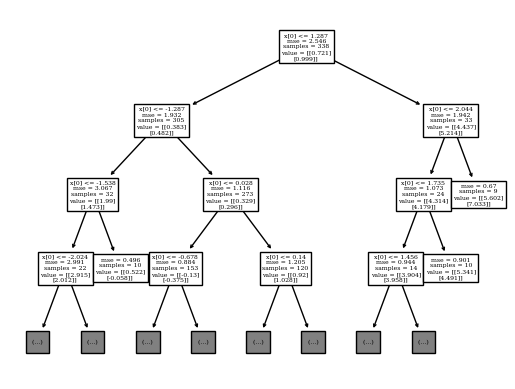

In [10]:
tree = cfdml.model[0][0]
plot_tree(tree, max_depth=3)

In [118]:
# for max_depth in [2, 3, 4, 5, 6, 7, 8, 9, 10]:
#     print(f"\nMax_depth = {max_depth}")
#     cfdml = CausalForestDML(
#         n_treatments=2, model_t=LogisticRegression(C=0.01), model_y=Lasso(alpha=0.01), 
#         n_estimators=100, max_depth=max_depth, n_jobs=-1, discrete_treatment=True
#     ).fit(X=cust_features, Y=outcomes, T=treatments)

#     avg_var = np.mean(cfdml.predict_incremental_effect(oos_cust_features)[1])
#     print(f"Average variance = {avg_var}")

#     plot_hte(dgp, model=cfdml, ci=True)

# Selection

In [119]:
selection, val_est = optimize(cfdml, oos_cust_features)

# Evaluation

In [120]:
val_true = obj_func(
    selection=selection, 
    cust_feautres=oos_cust_features, 
    demand_model=dgp,
)

result_df = pd.DataFrame({
    'Policy Value': [val_est, val_true, val_est - val_true]
}, index=['Estimated', 'True', "Winner's Curse"])
result_df

,Policy Value
Estimated,4.234721
True,4.279313
Winner's Curse,-0.044593


In [121]:
del dgp, cfdml, selection, val_est, val_true, result_df 
del cust_features, treatments, outcomes, oos_cust_features

# Winner's Curse

In [65]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1 + i * 0.05) for i in range(2)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x + 1, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}


data_params = {'sample_size': 500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_outcome': False, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {}

In [66]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    9.5s finished


In [67]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / np.sqrt(wc_arr.shape[0])

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')


Selection with Rank and Select:
  - Average True Value: 1.0315 (0.0051)
  - Average Estimated Value: 1.1026 (0.0058)
  - Average Winner's Curse (%): 142.27% (5.90%)


# Estimating Winner's Curse

In [107]:
dgp = Targeting(**dgp_params)

cust_features, treatments, outcomes = dgp.sample(data_params['sample_size'], seed=19)
oos_cust_features = dgp.sample_individuals(data_params['sample_size'], seed=19 + 10000)

## Standard Bootstrap

In [9]:
boot_wc_dstn_dict = get_wc_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=500, 
    emp_targ_te_arr=None, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.2s finished


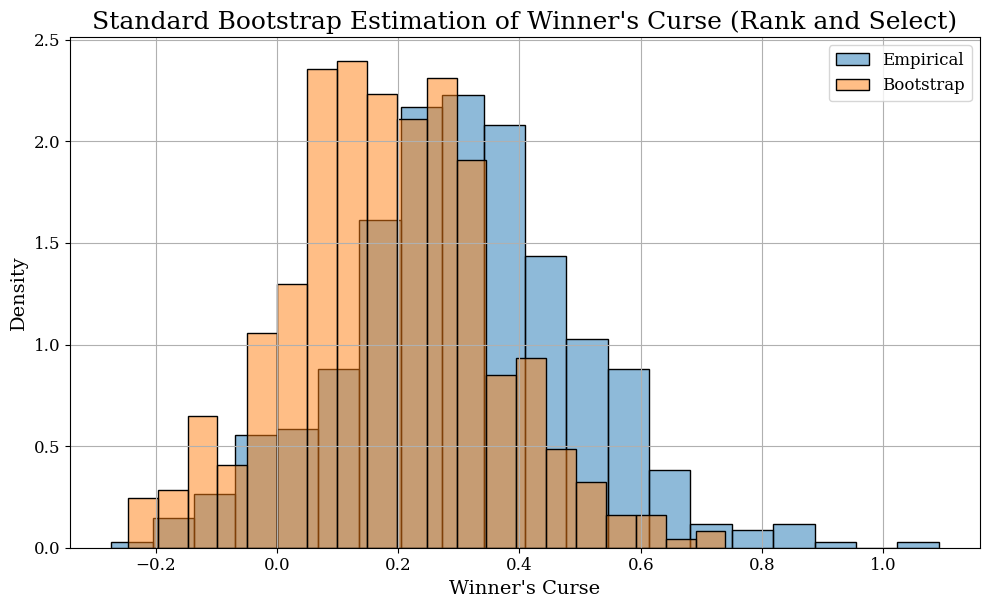

In [10]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.set_title(f'Standard Bootstrap Estimation of Winner\'s Curse ({display_name})', fontsize=title_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [11]:
boot_wc_dstn_dict = get_wc_m_out_of_n_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=500, 
    emp_targ_te_arr=None, 
    power=0.95, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.6s finished


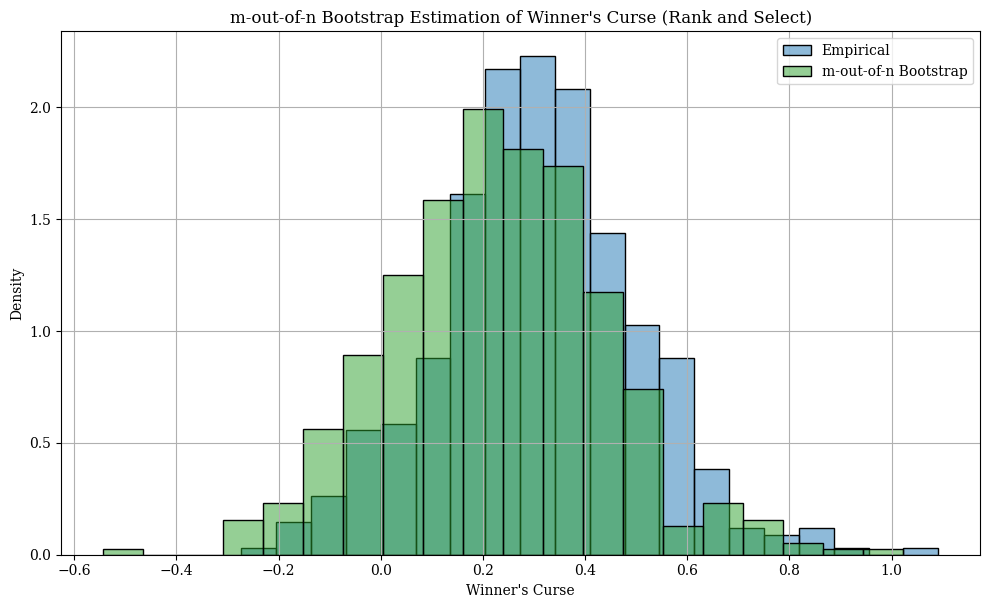

In [12]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'm-out-of-n Bootstrap Estimation of Winner\'s Curse ({display_name})')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [13]:
boot_wc_dstn_dict = get_wc_num_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=500, 
    emp_targ_te_arr=None, 
    power=-0.45, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.2s finished


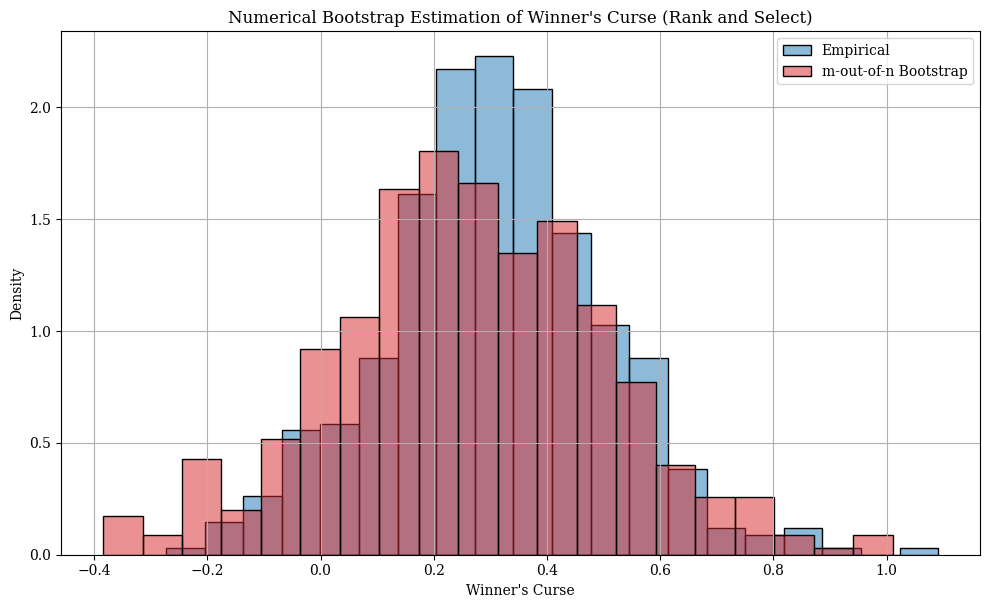

In [14]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'Numerical Bootstrap Estimation of Winner\'s Curse ({display_name})')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [87]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.05)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5}, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Bayes'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    'hybrid_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI'
    }, 
}

In [ ]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


In [12]:
with open('results/targeting_bias_correction.pkl', 'wb') as f:
    pickle.dump(wc_measures_dict, f)

with open('results/targeting_bias_correction.pkl', 'rb') as f:
    wc_measures_dict = pickle.load(f)


Selection with Rank and Select:
Policy Value: 
  - True Value: 1.0320 (0.0242)
  - No Correction: 0.8696 (0.0205)
  - Standard Bootstrap: 0.7641 (0.0233)
  - m-out-of-n Bootstrap: 0.6285 (0.0239)
  - Numerical Bootstrap: 0.7185 (0.0249)
  - Empirical Bayes: 0.8208 (0.0189)
  - Conditional SI: -0.3444 (0.0460)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: -324.80% (30.81%)
  - Standard Bootstrap: -535.94% (38.35%)
  - m-out-of-n Bootstrap: -807.06% (43.45%)
  - Numerical Bootstrap: -627.11% (42.37%)
  - Empirical Bayes: -422.39% (31.22%)
  - Conditional SI: -2745.74% (85.81%)
Median Winner's Curse: 
  - No Correction: -157.74% (30.81%)
  - Standard Bootstrap: -357.45% (38.35%)
  - m-out-of-n Bootstrap: -576.34% (43.45%)
  - Numerical Bootstrap: -435.71% (42.37%)
  - Empirical Bayes: -259.06% (31.22%)
  - Conditional SI: -2315.60% (85.81%)

Sample Splitting: 
  - True Value: 1.0370 (0.0246)
  - Estimated Value: 1.0215 (0.0223)
  - Winner's Curse (%): -20.98% (24.98%)


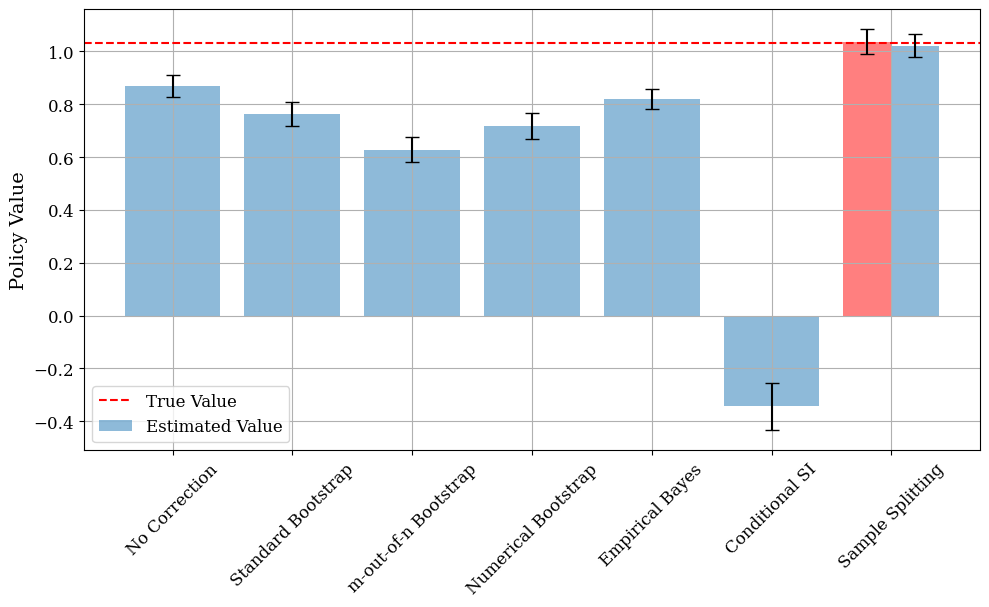

In [13]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

optimizer_key = 'rank_and_select'

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()], 
        rotation=45, 
        fontsize=tick_label_size
    )
# ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


In [14]:
optimizer_key= 'rank_and_select'
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean
latex_dict = {}

# true value
val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
latex_dict["True Value"] = {
    'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${val_true_avg:.4f}$\\\\ (${val_true_se:.4f}$)" + "\end{tabular}", 
    r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${0:.2f}\%$\\\\ (${0:.2f}\%$)" + "\end{tabular}"
}

for e_key in ['nc'] + list(estimators_dict.keys()):
    if e_key == 'sample_splitting':
        continue
    
    est_mean = wc_measures_dict[f'{optimizer_key}_{e_key}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{e_key}_val_est_se']

    wc_mean = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_{e_key}_wc_avg']
    wc_se = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_{e_key}_wc_se']
    wc_sig_level = significance_level(wc_mean, wc_se)
    wc_sig_level = '^{' + wc_sig_level + '}' if wc_sig_level != '' else ''

    e_name =  estimators_dict[e_key]['display_name'] if e_key != 'nc' else 'No Correction'

    latex_dict[e_name] = {
        'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${est_mean:.4f}" + f"$\\\\ (${est_se:.4f}$)" + "\end{tabular}", 
        r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + wc_sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    }

# sample splitting
ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']

ss_wc_avg = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
ss_wc_se = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']
ss_wc_sig_level = significance_level(ss_wc_avg, ss_wc_se)
ss_wc_sig_level = '^{' + ss_wc_sig_level + '}' if ss_wc_sig_level != '' else ''
latex_dict["Sample Splitting"] = {
    'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_est_avg:.4f}" + f"$\\\\ (${ss_val_est_se:.4f}$)" + "\end{tabular}",
    r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_wc_avg:.2f}\%" + ss_wc_sig_level + f"$\\\\ (${ss_wc_se:.2f}\%$)" + "\end{tabular}"
}

latex_df = pd.DataFrame(latex_dict).T
print(latex_df.style.to_latex(
    column_format='ccc',  
    hrules=True
))

\begin{tabular}{ccc}
\toprule
 & Policy Value & \begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular} \\
\midrule
True Value & \begin{tabular}[c]{@{}c@{}}$1.0320$\\ ($0.0242$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.00\%$\\ ($0.00\%$)\end{tabular} \\
No Correction & \begin{tabular}[c]{@{}c@{}}$0.8696$\\ ($0.0205$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-324.80\%^{***}$\\ ($30.81\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.7641$\\ ($0.0233$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-535.94\%^{***}$\\ ($38.35\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.6285$\\ ($0.0239$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-807.06\%^{***}$\\ ($43.45\%$)\end{tabular} \\
Numerical Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.7185$\\ ($0.0249$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-627.11\%^{***}$\\ ($42.37\%$)\end{tabular} \\
Empirical Bayes & \begin{tabular}[c]{@{}c@{}}$0.8208$\\ ($0.0189$)\end{tabular

In [15]:
nc_val_true_avg  = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
nc_val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
clairvoyant_val = np.max([var.mean for var in dgp_params['base_effect_vars']])
policy_comp_dict = {
    'Clairvoyant Policy': {'Policy Value': f"{clairvoyant_val:.4f}"}, 
    'Focal Policy': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${nc_val_true_avg:.4f}" + f"$\\\\ (${nc_val_true_se:.4f}$)" + "\end{tabular}"},
}

ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
random_val = np.mean([var.mean for var in dgp_params['base_effect_vars']])
policy_comp_dict.update({
    'Sample Splitting': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_true_avg:.4f}" + f"$\\\\ (${ss_val_true_se:.4f}$)" + "\end{tabular}"}, 
    'Random Guessing': {'Policy Value': f'{random_val:.4f}'},
})

policy_comp_df = pd.DataFrame(policy_comp_dict).T
print(policy_comp_df.style.to_latex(
    column_format='cc',  
    hrules=True
))

\begin{tabular}{cc}
\toprule
 & Policy Value \\
\midrule
Clairvoyant Policy & 1.0500 \\
Focal Policy & \begin{tabular}[c]{@{}c@{}}$1.0320$\\ ($0.0242$)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$1.0370$\\ ($0.0246$)\end{tabular} \\
Random Guessing & 1.0250 \\
\bottomrule
\end{tabular}



# Comparative Statics

## Delta Tau

In [79]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [None, None], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Shrinkage'
    # }, 
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    'hybrid_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI'
    }, 
}

tau_list = [
    (1, 1.01), (1, 1.025), (1, 1.05), 
    # (1, 1.1), (2, 2.1), (3, 3.1), (1, 1.5)
]

In [80]:
tau_result_dict = {tau: None for tau in tau_list}

for te_tuple in tau_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effect_vars'] = [PointMass(te_tuple[0]), PointMass(te_tuple[1])]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, 
        n_jobs=-1
    )

    tau_result_dict[te_tuple] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


(tau_1, tau_2)= (1, 1.01)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 14.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 38.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 48.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (1, 1.025)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 15.0min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 39.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 49.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (1, 1.05)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 15.3min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 39.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 49.6min finished


In [81]:
with open('results/targeting_delta_tau.pkl', 'wb') as f:
    pickle.dump(tau_result_dict, f)

with open('results/targeting_delta_tau.pkl', 'rb') as f:
    tau_result_dict = pickle.load(f)

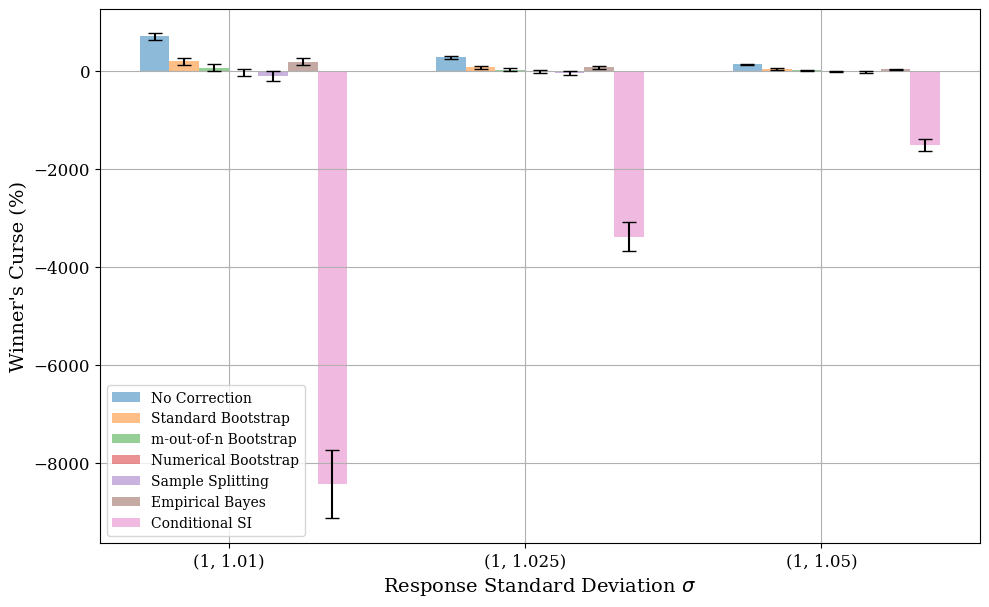

$\Delta\tau = 0.01$  \
                            $(\tau_1, \tau_2)$ = (1, 1.01)   
No Correction        Mean                           701.36   
                     Median                         680.01   
                     S.E.                            33.66   
Standard Bootstrap   Mean                           196.62   
                     Median                         190.86   
                     S.E.                            37.64   
m-out-of-n Bootstrap Mean                            63.44   
                     Median                          39.09   
                     S.E.                            37.89   
Numerical Bootstrap  Mean                           -33.93   
                     Median                         -40.15   
                     S.E.                            39.81   
Sample Splitting     Mean                           -98.96   
                     Median                        -111.93   
                     S.E.                            50.37   
Empirical Bayes      Mean                           187.53   
                     Median                         192.82   
                     S.E.                            34.30   
Conditional SI       Mean                         -8446.52   
                     Median                       -5714.34   
                     S.E.                           354.85   

                                        $\Delta\tau = 0.02$  \
                            $(\tau_1, \tau_2)$ = (1, 1.025)   
No Correction        Mean                            277.42   
                     Median                          268.72   
                     S.E.                             13.51   
Standard Bootstrap   Mean                             75.73   
                     Median                           63.47   
                     S.E.                             15.12   
m-out-of-n Bootstrap Mean                             20.55   
                     Median                           11.55   
                     S.E.                             15.11   
Numerical Bootstrap  Mean                            -14.36   
                     Median                          -15.02   
                     S.E.                             15.91   
Sample Splitting     Mean                            -43.48   
                     Median                          -46.34   
                     S.E.                             20.68   
Empirical Bayes      Mean                             71.70   
                     Median                           77.52   
                     S.E.                             13.77   
Conditional SI       Mean                          -3383.93   
                     Median                        -2330.04   
                     S.E.                            147.96   

                                       $\Delta\tau = 0.05$  
                            $(\tau_1, \tau_2)$ = (1, 1.05)  
No Correction        Mean                           132.96  
                     Median                         128.96  
                     S.E.                             6.81  
Standard Bootstrap   Mean                            33.76  
                     Median                          30.68  
                     S.E.                             7.60  
m-out-of-n Bootstrap Mean                             7.02  
                     Median                           4.85  
                     S.E.                             7.64  
Numerical Bootstrap  Mean                           -10.89  
                     Median                          -6.56  
                     S.E.                             7.98  
Sample Splitting     Mean                           -22.99  
                     Median                         -14.55  
                     S.E.                             9.74  
Empirical Bayes      Mean                            30.81  
                     Median                          34.23  
   

In [82]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = tau_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    data[key]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[key][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (f'$\\Delta\tau = {np.round(key[1] - key[0], 2)}$', '$(\tau_1, \tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[key][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(tau_list))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in tau_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(tau_list)), labels=tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [83]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = tau_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    wc_mean = result_dict[key][f'{optimizer_key}_nc_wc_avg'] / delta_tau * 100
    wc_se = result_dict[key][f'{optimizer_key}_nc_wc_se'] / delta_tau * 100
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[key]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / delta_tau * 100
        wc_se = result_dict[key][f'{optimizer_key}_{est_key}_wc_se'] / delta_tau * 100
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[key][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

# Create the MultiIndex DataFrame
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\\tau = {np.round(key[1] - key[0], 2)}$', '$(\\tau_1, \\tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
            column_data.append(data[key][est_name])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
latex_df = pd.DataFrame(
    np.array(df_data).T,
    index=estimator_names,
    columns=col_index
)
print(latex_df.style.to_latex(
    column_format='c' * (2 * 3 + 1), 
    hrules=True
))


\begin{tabular}{ccccccc}
\toprule
 & $\Delta\tau = 0.01$ & $\Delta\tau = 0.02$ & $\Delta\tau = 0.05$ \\
 & $(\tau_1, \tau_2)$ = (1, 1.01) & $(\tau_1, \tau_2)$ = (1, 1.025) & $(\tau_1, \tau_2)$ = (1, 1.05) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$701.36\%^{***}$\\ ($33.66$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$277.42\%^{***}$\\ ($13.51$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$132.96\%^{***}$\\ ($6.81$)\%\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$196.62\%^{***}$\\ ($37.64$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$75.73\%^{***}$\\ ($15.12$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$33.76\%^{***}$\\ ($7.60$)\%\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$63.44\%^{*}$\\ ($37.89$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$20.55\%$\\ ($15.11$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$7.02\%$\\ ($7.64$)\%\end{tabular} \\
Numerical Bootstrap & \begin{tabular}[c]{@{}c@{}}$-33.93\%$\\ ($39.81$)\%\end{tabular}

In [84]:
policy_comp_dict = {
    'Clairvoyant Policy': {}, 
    'Policy (Entire Dataset)': {},
    'Policy (Half Dataset)': {},
    'Random Guessing': {}, 
}

for delta_tau_tuple, wc_measures_dict in tau_result_dict.items():
    delta_tau = delta_tau_tuple[1] - delta_tau_tuple[0]
    ratio = delta_tau / 1.0 * 100
    # clairvoyant policy
    clairvoyant_val = 1 + delta_tau
    policy_comp_dict['Clairvoyant Policy'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = f"{clairvoyant_val:.4f}"

    # focal policy
    nc_val_true_avg  = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
    nc_val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
    policy_comp_dict['Policy (Entire Dataset)'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${nc_val_true_avg:.4f}" + f"$\\\\ (${nc_val_true_se:.4f}$)" + "\end{tabular}"

    # sample splitting
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    policy_comp_dict['Policy (Half Dataset)'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_true_avg:.4f}" + f"$\\\\ (${ss_val_true_se:.4f}$)" + "\end{tabular}"

    # random guessing policy 
    random_val = 1 + delta_tau / 2 
    policy_comp_dict['Random Guessing'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = f'{random_val:.4f}'

# Create DataFrame
policy_comp_df = pd.DataFrame(policy_comp_dict).T 
policy_comp_df
print(policy_comp_df.style.to_latex(
    column_format='cccc',  
    hrules=True
))

\begin{tabular}{cccc}
\toprule
 & $\Delta\tau / \sigma = 1.0\%$ & $\Delta\tau / \sigma = 2.5\%$ & $\Delta\tau / \sigma = 5.0\%$ \\
\midrule
Clairvoyant Policy & 1.0100 & 1.0250 & 1.0500 \\
Policy (Entire Dataset) & \begin{tabular}[c]{@{}c@{}}$1.0041$\\ ($0.0077$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0134$\\ ($0.0078$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0319$\\ ($0.0080$)\end{tabular} \\
Policy (Half Dataset) & \begin{tabular}[c]{@{}c@{}}$1.0041$\\ ($0.0077$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0134$\\ ($0.0078$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0302$\\ ($0.0079$)\end{tabular} \\
Random Guessing & 1.0050 & 1.0125 & 1.0250 \\
\bottomrule
\end{tabular}



## Sample Size

In [8]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.05)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': None, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Bayesian'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    },
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

sample_size_list = [100, 500, 1000, 2500, 5000, 10000]

In [9]:
sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size= {sample_size}')

    data_params['sample_size'] = sample_size    

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, 
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Sample Size= 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.2min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 11.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 33.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 42.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 1000
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 30.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 82.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 104.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 5000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 62.0min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 164.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 206.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 10000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 149.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 389.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 476.5min finished


In [10]:
with open('results/targeting_sample_size.pkl', 'wb') as f:
    pickle.dump(sample_size_result_dict, f)

with open('results/targeting_sample_size.pkl', 'rb') as f:
    sample_size_result_dict = pickle.load(f)

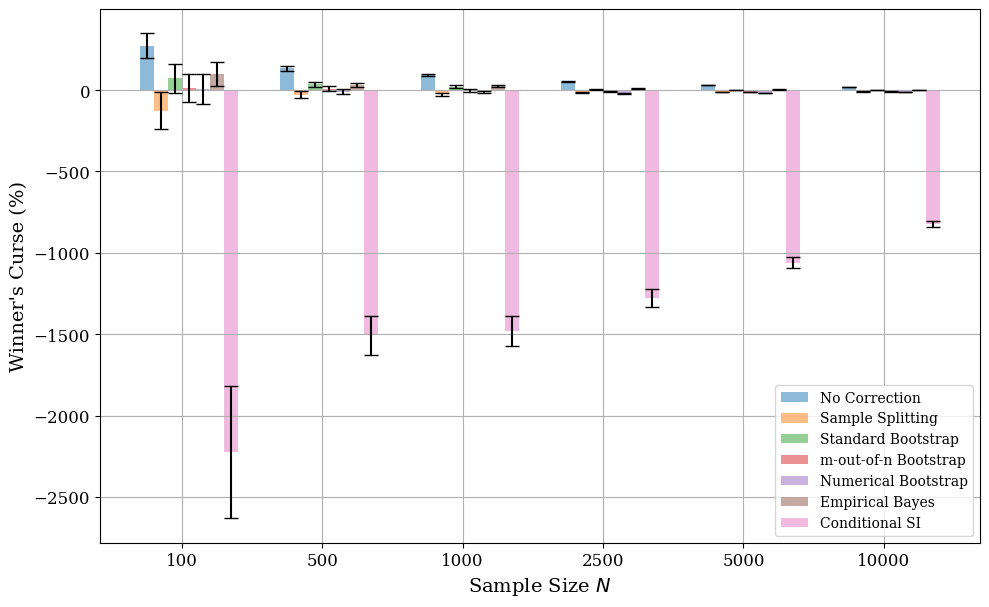

$N=100$  $N=500$  $N=1000$  $N=2500$  $N=5000$  \
No Correction        Mean     272.44   132.96     91.82     51.63     30.15   
                     Median   267.71   128.96     92.20     52.13     30.86   
                     S.E.      38.97     6.81      3.38      1.45      0.81   
Sample Splitting     Mean    -126.84   -28.03    -25.18    -13.11    -12.97   
                     Median   -74.25   -23.99    -19.36    -12.03    -12.04   
                     S.E.      57.07    10.41      5.04      2.01      1.10   
Standard Bootstrap   Mean      71.38    34.20     21.60      6.22      0.92   
                     Median    70.53    30.62     23.01      9.33      2.11   
                     S.E.      44.58     7.58      3.76      1.62      0.89   
m-out-of-n Bootstrap Mean      12.85     7.25     -1.95    -11.07    -11.55   
                     Median    -0.41     5.02      1.59     -7.76    -11.47   
                     S.E.      43.71     7.57      3.72      1.65      0.89   
Numerical Bootstrap  Mean       5.43   -11.02    -12.90    -19.34    -17.23   
                     Median   -17.59    -9.37    -12.32    -14.22    -14.18   
                     S.E.      46.96     8.01      4.01      1.75      0.96   
Empirical Bayes      Mean      99.83    30.81     23.41     11.40      2.93   
                     Median    92.94    34.23     23.24     18.82     10.56   
                     S.E.      38.11     6.95      3.48      1.45      0.87   
Conditional SI       Mean   -2224.64 -1508.15  -1480.76  -1279.96  -1060.64   
                     Median -1566.04 -1086.92  -1040.77   -752.58   -676.90   
                     S.E.     208.12    61.85     47.34     28.49     17.08   

                             $N=10000$  
No Correction        Mean        17.13  
                     Median      17.41  
                     S.E.         0.44  
Sample Splitting     Mean        -8.62  
                     Median      -3.90  
                     S.E.         0.57  
Standard Bootstrap   Mean        -0.67  
                     Median       1.78  
                     S.E.         0.49  
m-out-of-n Bootstrap Mean        -9.81  
                     Median      -8.07  
                     S.E.         0.49  
Numerical Bootstrap  Mean       -12.44  
                     Median     -11.52  
                     S.E.         0.52  
Empirical Bayes      Mean         0.13  
                     Median       2.16  
                     S.E.         0.45  
Conditional SI       Mean      -822.59  
                     Median    -516.97  
                     S.E.        10.04

In [13]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[sample_size]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[sample_size][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$N={sample_size}$' for sample_size in sample_size_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccc}
\toprule
 & $N=100$ & $N=500$ & $N=1000$ & $N=2500$ & $N=5000$ & $N=10000$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$272.44\%^{***}$\\ ($38.97\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$132.96\%^{***}$\\ ($6.81\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$91.82\%^{***}$\\ ($3.38\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$51.63\%^{***}$\\ ($1.45\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$30.15\%^{***}$\\ ($0.81\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$17.13\%^{***}$\\ ($0.44\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$71.38\%$\\ ($44.58\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$34.20\%^{***}$\\ ($7.58\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$21.60\%^{***}$\\ ($3.76\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$6.22\%^{***}$\\ ($1.62\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.92\%$\\ ($0.89\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.67\%$\\ ($0.49\%$)\end{tabular} \\
m-out-of-n Bo

## Response STD

In [41]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': None, 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Shrinkage'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    },
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

response_std_list = [0.5, 1, 2, 3, 4, 5]

In [99]:
response_std_result_dict = {response_std: None for response_std in response_std_list}

for response_std in response_std_list:
    print(f'\nNoise Standard Deviation= {response_std}')

    dgp_params['noise_var'] = UnivariateGaussian(0, response_std)  

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, 
        n_jobs=1
    )

    response_std_result_dict[response_std] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Noise Standard Deviation= 0.5
Running 500 experiments...


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:  1.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.



Noise Standard Deviation= 1
Running 500 experiments...


[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:  1.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.



Noise Standard Deviation= 2
Running 500 experiments...


...

[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:  1.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.



Noise Standard Deviation= 4
Running 500 experiments...


[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:  1.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.



Noise Standard Deviation= 5
Running 500 experiments...


[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:  1.1min finished


In [42]:
# with open('results/targeting_response_std.pkl', 'wb') as f:
#     pickle.dump(response_std_result_dict, f)

with open('results/targeting_response_std.pkl', 'rb') as f:
    response_std_result_dict = pickle.load(f)

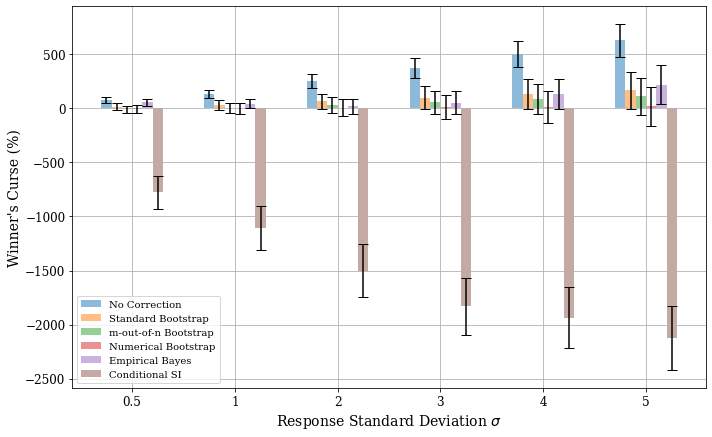

$\sigma=0.5$  $\sigma=1$  $\sigma=2$  $\sigma=3$  \
No Correction        Mean           78.00      130.72      249.76      374.32   
                     Median         80.32      124.98      258.49      386.94   
                     S.E.           14.78       19.89       33.02       47.37   
Standard Bootstrap   Mean           13.89       31.81       63.96       97.61   
                     Median          5.42       30.06       45.59       83.37   
                     S.E.           17.03       22.65       37.15       53.40   
m-out-of-n Bootstrap Mean           -9.93        3.23       29.11       57.21   
                     Median        -17.02        7.87       24.52       43.21   
                     S.E.           16.56       22.18       37.31       53.96   
Numerical Bootstrap  Mean           -7.16       -1.32        6.83       10.96   
                     Median        -16.84      -11.86       -5.26       -6.50   
                     S.E.           18.22       23.94       39.08       56.29   
Empirical Bayes      Mean           54.81       42.42       18.98       52.78   
                     Median         46.53       41.40       14.94       69.48   
                     S.E.           17.24       21.65       35.37       53.45   
Conditional SI       Mean         -778.27    -1106.05    -1502.88    -1831.24   
                     Median       -564.30     -805.94    -1262.16    -1591.80   
                     S.E.           78.54      104.41      125.60      135.18   

                             $\sigma=4$  $\sigma=5$  
No Correction        Mean        501.77      630.13  
                     Median      519.39      642.96  
                     S.E.         62.23       77.25  
Standard Bootstrap   Mean        135.09      166.42  
                     Median      121.50      176.77  
                     S.E.         70.08       87.07  
m-out-of-n Bootstrap Mean         88.72      111.44  
                     Median       90.82      120.23  
                     S.E.         71.18       88.08  
Numerical Bootstrap  Mean         13.51       18.17  
                     Median       -7.00        2.42  
                     S.E.         74.14       91.57  
Empirical Bayes      Mean        132.00      217.48  
                     Median      187.06      277.58  
                     S.E.         72.47       91.49  
Conditional SI       Mean      -1937.45    -2127.18  
                     Median    -1770.98    -2037.11  
                     S.E.        143.31      151.48

In [43]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = response_std_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for response_std in response_std_list:
    data[response_std] = {}

    data[response_std]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[response_std][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for response_std in response_std_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[response_std][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\sigma={}$'.format(p) for p in response_std_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(response_std_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in response_std_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in response_std_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(response_std_list)), labels=response_std_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [46]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = response_std_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for response_std in response_std_list:
    data[response_std] = {}

    wc_mean = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[response_std]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[response_std][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$\sigma={response_std}$' for response_std in response_std_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(response_std_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccc}
\toprule
 & $\sigma=0.5$ & $\sigma=1$ & $\sigma=2$ & $\sigma=3$ & $\sigma=4$ & $\sigma=5$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$78.00\%^{***}$\\ ($14.78\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$130.72\%^{***}$\\ ($19.89\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$249.76\%^{***}$\\ ($33.02\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$374.32\%^{***}$\\ ($47.37\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$501.77\%^{***}$\\ ($62.23\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$630.13\%^{***}$\\ ($77.25\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$13.89\%$\\ ($17.03\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$31.81\%$\\ ($22.65\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$63.96\%^{*}$\\ ($37.15\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$97.61\%^{*}$\\ ($53.40\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$135.09\%^{*}$\\ ($70.08\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$166.42\%^{*}$\\ ($87.07\%$)

## Functional Form

In [12]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.05)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': None, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Bayesian'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

char_func_dict = {
    r'$x$': lambda x: x,
    r'$x^2 + x$': lambda x: x**2 + x,
    r'$x^3$': lambda x: x**3,
    r'$|x|$': lambda x: np.abs(x),
}

In [13]:
char_func_result_dict = {k: None for k in char_func_dict.keys()}
for char_func in char_func_dict.keys():
    print(f'\nCharacterizing Function= {char_func}')

    dgp_params['char_func'] = char_func_dict[char_func]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    char_func_result_dict[char_func] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )



Characterizing Function= $x$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 13.4min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 35.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 45.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Characterizing Function= $x^2 + x$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 12.2min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 33.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 43.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Characterizing Function= $x^3$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 12.4min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 34.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 44.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Characterizing Function= $|x|$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 12.5min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 34.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 44.6min finished


In [14]:
with open('results/targeting_char_func.pkl', 'wb') as f:
    pickle.dump(char_func_result_dict, f)

with open('results/targeting_char_func.pkl', 'rb') as f:
    char_func_result_dict = pickle.load(f)

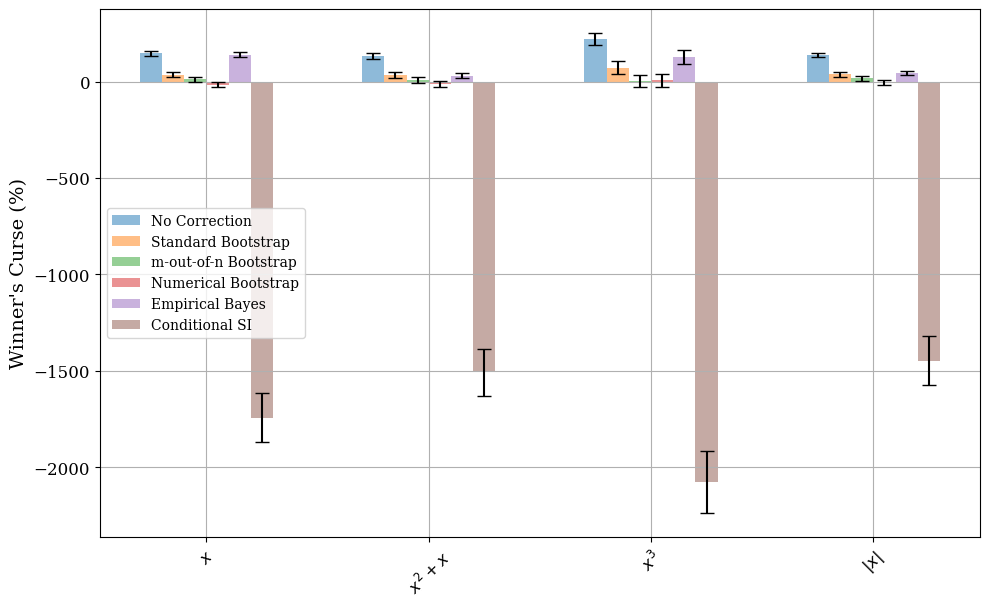

$x$  $x^2 + x$    $x^3$    $|x|$
No Correction        Mean     146.75     132.96   219.90   136.46
                     Median   143.63     128.96   221.35   134.17
                     S.E.       5.88       6.81    16.38     5.78
Standard Bootstrap   Mean      34.34      34.36    72.36    37.60
                     Median    38.23      30.75    72.55    32.86
                     S.E.       6.62       7.59    17.24     6.49
m-out-of-n Bootstrap Mean      11.95       8.51     4.03    16.93
                     Median    14.31       2.16    -2.22    11.70
                     S.E.       6.68       7.62    16.65     6.58
Numerical Bootstrap  Mean     -16.41     -10.60     5.73    -6.83
                     Median   -21.22      -6.49     4.43   -13.49
                     S.E.       7.02       8.05    17.80     6.86
Empirical Bayes      Mean     139.85      30.81   126.97    43.54
                     Median   136.35      34.23   138.04    39.85
                     S.E.       5.94       6.95    18.86     5.88
Conditional SI       Mean   -1742.45   -1508.15 -2075.72 -1447.80
                     Median -1294.69   -1086.92 -1584.80  -979.19
                     S.E.      64.73      61.85    82.40    64.67

In [15]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = char_func_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for char_func in char_func_dict.keys():
    data[char_func] = {}

    data[char_func]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[char_func][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[char_func][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[char_func][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in char_func_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(char_func_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(char_func_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in char_func_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in char_func_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(char_func_dict.keys())), 
    labels=char_func_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [16]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = char_func_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for char_func in char_func_dict.keys():
    data[char_func] = {}

    wc_mean = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[char_func]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[char_func][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [char_func for char_func in char_func_dict.keys()]
print(latex_df.style.to_latex(
    column_format='c' * (len(char_func_dict) + 1), 
    hrules=True
))

\begin{tabular}{ccccc}
\toprule
 & $x$ & $x^2 + x$ & $x^3$ & $|x|$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$146.75\%^{***}$\\ ($5.88\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$132.96\%^{***}$\\ ($6.81\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$219.90\%^{***}$\\ ($16.38\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$136.46\%^{***}$\\ ($5.78\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$34.34\%^{***}$\\ ($6.62\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$34.36\%^{***}$\\ ($7.59\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$72.36\%^{***}$\\ ($17.24\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$37.60\%^{***}$\\ ($6.49\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$11.95\%^{*}$\\ ($6.68\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$8.51\%$\\ ($7.62\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$4.03\%$\\ ($16.65\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$16.93\%^{**}$\\ ($6.58\%$)\end{tabular} \\
Numerical Bootst

## Noise Distribution

In [10]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.05)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': None, 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Shrinkage'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    },
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

noise_dstn_dict = {
    'Normal(0, 1)': UnivariateGaussian(0, std=1),
    'Uniform($-\\sqrt{3}$, $-\\sqrt{3}$)': Uniform(-3**0.5, 3**0.5),
    r'Laplace(0, $1/\sqrt{2}$)': Laplace(0, 1 / np.sqrt(2)), 
    r'Logistic(0, $\sqrt{3} / \pi$)': Logistic(0, np.sqrt(3) / np.pi), 
}

In [17]:
noise_dstn_result_dict = {k: None for k in noise_dstn_dict.keys()}

for noise_dstn in noise_dstn_dict.keys():
    print(f'\nNoise Distribution= {noise_dstn}')

    dgp_params['noise_var'] = noise_dstn_dict[noise_dstn]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=1
    )

    noise_dstn_result_dict[noise_dstn] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Noise Distribution= Normal(0, 1)
Running 500 experiments...


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed: 45.5min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.



Noise Distribution= Uniform($-\sqrt{3}$, $-\sqrt{3}$)
Running 500 experiments...


[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed: 46.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.



Noise Distribution= Laplace(0, $1/\sqrt{2}$)
Running 500 experiments...


[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed: 46.3min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.



Noise Distribution= Logistic(0, $\sqrt{3} / \pi$)
Running 500 experiments...


[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed: 46.4min finished


In [11]:
# with open('results/targeting_noise_dstn.pkl', 'wb') as f:
#     pickle.dump(noise_dstn_result_dict, f)

with open('results/targeting_noise_dstn.pkl', 'rb') as f:
    noise_dstn_result_dict = pickle.load(f)

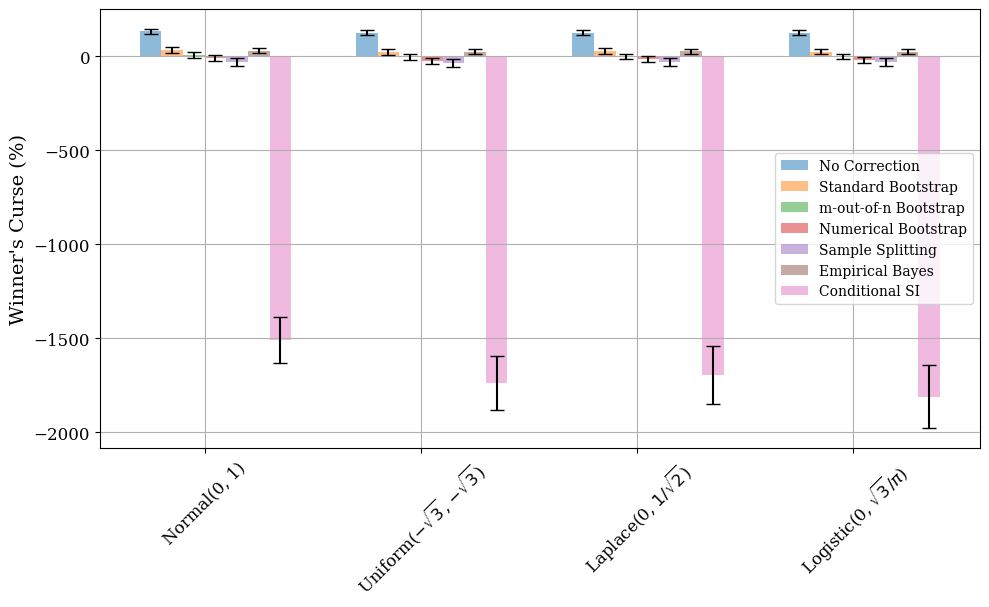

Normal(0, 1)  Uniform($-\sqrt{3}$, $-\sqrt{3}$)  \
No Correction        Mean          132.96                             125.15   
                     Median        128.96                             126.74   
                     S.E.            6.81                               6.84   
Standard Bootstrap   Mean           35.09                              22.52   
                     Median         32.92                              14.55   
                     S.E.            7.58                               7.64   
m-out-of-n Bootstrap Mean            7.97                              -2.74   
                     Median         -0.93                             -12.91   
                     S.E.            7.68                               7.73   
Numerical Bootstrap  Mean          -10.45                             -22.42   
                     Median        -13.53                             -33.05   
                     S.E.            7.97                               8.11   
Sample Splitting     Mean          -28.03                             -35.01   
                     Median        -23.99                             -25.11   
                     S.E.           10.41                              10.67   
Empirical Bayes      Mean           30.81                              24.47   
                     Median         34.23                              26.73   
                     S.E.            6.95                               6.97   
Conditional SI       Mean        -1508.15                           -1738.37   
                     Median      -1086.92                           -1160.48   
                     S.E.           61.85                              73.03   

                             Laplace(0, $1/\sqrt{2}$)  \
No Correction        Mean                      126.79   
                     Median                    128.88   
                     S.E.                        6.79   
Standard Bootstrap   Mean                       27.86   
                     Median                     21.95   
                     S.E.                        7.63   
m-out-of-n Bootstrap Mean                        0.13   
                     Median                     -3.78   
                     S.E.                        7.71   
Numerical Bootstrap  Mean                      -15.93   
                     Median                    -13.10   
                     S.E.                        8.01   
Sample Splitting     Mean                      -29.28   
                     Median                    -26.38   
                     S.E.                       10.66   
Empirical Bayes      Mean                       26.48   
                     Median                     30.25   
                     S.E.                        6.87   
Conditional SI       Mean                    -1695.12   
                     Median                  -1122.95   
                     S.E.                       79.13   

                             Logistic(0, $\sqrt{3} / \pi$)  
No Correction        Mean                           126.45  
                     Median                         129.46  
                     S.E.                             6.80  
Standard Bootstrap   Mean                            25.60  
                     Median                          30.37  
                     S.E.                             7.57  
m-out-of-n Bootstrap Mean                            -0.98  
                     Median                          -9.14  
                     S.E.                             7.68  
Numerical Bootstrap  Mean                           -18.50  
                     Median                         -21.64  
                     S.E.                             8.13  
Sample Splitting     Mean                           -30.17  
                     Median                         -18.45  
                     S.E.                            10.63  
Empirical Bayes      Mean            

In [12]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = noise_dstn_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for noise_dstn in noise_dstn_dict.keys():
    data[noise_dstn] = {}

    data[noise_dstn]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[noise_dstn][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in noise_dstn_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(noise_dstn_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(noise_dstn_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in noise_dstn_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in noise_dstn_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(noise_dstn_dict.keys())), 
    labels=noise_dstn_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [14]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = noise_dstn_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean
# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for noise_dstn in noise_dstn_dict.keys():
    data[noise_dstn] = {}

    wc_mean = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[noise_dstn]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[noise_dstn][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = list(noise_dstn_dict.keys())
print(latex_df.style.to_latex(
    column_format='c' * (len(noise_dstn_dict) + 1), 
    hrules=True
))

\begin{tabular}{ccccc}
\toprule
 & Normal(0, 1) & Uniform($-\sqrt{3}$, $-\sqrt{3}$) & Laplace(0, $1/\sqrt{2}$) & Logistic(0, $\sqrt{3} / \pi$) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$132.96\%^{***}$\\ ($6.81\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$125.15\%^{***}$\\ ($6.84\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$126.79\%^{***}$\\ ($6.79\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$126.45\%^{***}$\\ ($6.80\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$35.09\%^{***}$\\ ($7.58\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$22.52\%^{***}$\\ ($7.64\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$27.86\%^{***}$\\ ($7.63\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$25.60\%^{***}$\\ ($7.57\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$7.97\%$\\ ($7.68\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-2.74\%$\\ ($7.73\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.13\%$\\ ($7.71\%$)\end{tabular} & \begin{tabular}[c]

## Multiple Treatments

In [15]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': None, 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': None, 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Shrinkage'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

n_treatments_list = [2, 4, 6, 8, 10]
delta_tau = 0.0

In [22]:
n_treatments_result_dict = {n_treatments: None for n_treatments in n_treatments_list}

for n_treatments in n_treatments_list:
    print(f'\nNumber of Treatments= {n_treatments}')

    dgp_params['base_effect_vars'] = [PointMass(1 + i * delta_tau) for i in range(n_treatments)]
    experiment_params['estimator']['params']['n_treatments'] = n_treatments

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    n_treatments_result_dict[n_treatments] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Number of Treatments= 2
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 11.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 34.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 43.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 21.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 60.0min
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 76.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 6
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 49.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 129.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 159.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 8
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 100.3min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 256.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 319.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 10
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 178.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 465.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 591.0min finished


In [16]:
# with open('results/targeting_n_treatments.pkl', 'wb') as f:
#     pickle.dump(n_treatments_result_dict, f)

with open('results/targeting_n_treatments.pkl', 'rb') as f:
    n_treatments_result_dict = pickle.load(f)

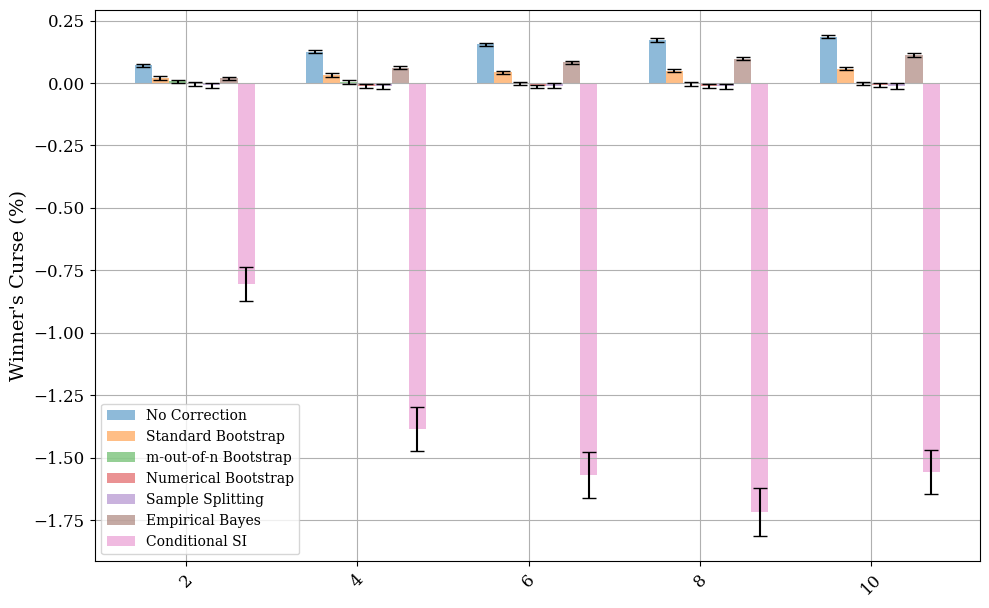

2     4     6     8     10
No Correction        Mean    0.07  0.13  0.15  0.17  0.19
                     Median  0.07  0.12  0.15  0.17  0.18
                     S.E.    0.00  0.00  0.00  0.00  0.00
Standard Bootstrap   Mean    0.02  0.03  0.04  0.05  0.06
                     Median  0.02  0.03  0.04  0.05  0.05
                     S.E.    0.00  0.00  0.00  0.00  0.00
m-out-of-n Bootstrap Mean    0.01  0.00 -0.00 -0.00 -0.00
                     Median  0.00 -0.00 -0.00 -0.00 -0.01
                     S.E.    0.00  0.00  0.00  0.00  0.00
Numerical Bootstrap  Mean   -0.00 -0.01 -0.01 -0.01 -0.01
                     Median -0.01 -0.02 -0.02 -0.01 -0.01
                     S.E.    0.00  0.00  0.00  0.00  0.00
Sample Splitting     Mean   -0.01 -0.01 -0.01 -0.01 -0.01
                     Median -0.01 -0.02 -0.01 -0.01 -0.02
                     S.E.    0.00  0.00  0.00  0.01  0.01
Empirical Bayes      Mean    0.02  0.06  0.08  0.10  0.11
                     Median  0.02  0.06  0.08  0.10  0.11
                     S.E.    0.00  0.00  0.00  0.00  0.00
Conditional SI       Mean   -0.81 -1.39 -1.57 -1.72 -1.56
                     Median -0.58 -1.12 -1.30 -1.44 -1.35
                     S.E.    0.03  0.04  0.05  0.05  0.05

In [17]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = n_treatments_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each
for n_treatments in n_treatments_list:
    data[n_treatments] = {}

    data[n_treatments]['No Correction'] = {
        'Mean': result_dict[n_treatments][f'{optimizer_key}_nc_wc_avg'],
        'Median': np.nanmedian(result_dict[n_treatments][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': result_dict[n_treatments][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = np.nanmedian(result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[n_treatments][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for n_treatments in n_treatments_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[n_treatments][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=n_treatments_list
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(n_treatments_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in n_treatments_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in n_treatments_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(n_treatments_list)), 
    labels=n_treatments_list, 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [19]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = n_treatments_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for n_treatments in n_treatments_list:
    data[n_treatments] = {}

    wc_mean = result_dict[n_treatments][f'{optimizer_key}_nc_wc_avg']
    wc_se = result_dict[n_treatments][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[n_treatments]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[n_treatments][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [n_treatments for n_treatments in n_treatments_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(n_treatments_list) + 1), 
    hrules=True
))

\begin{tabular}{cccccc}
\toprule
 & 2 & 4 & 6 & 8 & 10 \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$0.0703^{***}$\\ ($0.0034$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.1255^{***}$\\ ($0.0031$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.1545^{***}$\\ ($0.0031$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.1720^{***}$\\ ($0.0034$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.1855^{***}$\\ ($0.0034$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.0198^{***}$\\ ($0.0037$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0327^{***}$\\ ($0.0035$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0423^{***}$\\ ($0.0035$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0501^{***}$\\ ($0.0037$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0581^{***}$\\ ($0.0037$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.0063^{*}$\\ ($0.0038$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0037$\\ ($0.0034$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.0008$\\ 

## Customer Distribution

In [11]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.05)], 
    'cust_feat_var': None, 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Bayes'
    # }, 
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5}, 
        'display_name': 'Sample Splitting', 
    }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

cust_feat_var_dict = {
    'Normal(0, $1^2$)': UnivariateGaussian(0, std=1),
    'Uniform($-\\sqrt{3}$, $\\sqrt{3}$)': Uniform(-3**0.5, 3**0.5),
    r'Laplace(0, $1/\sqrt{2}$)': Laplace(0, 1 / np.sqrt(2)), 
    r'Logistic(0, $\sqrt{3} / \pi$)': Logistic(0, np.sqrt(3) / np.pi), 
}

In [22]:
cust_feat_var_result_dict = {k: None for k in cust_feat_var_dict.keys()}

for cust_feat_var in cust_feat_var_dict.keys():
    print(f'\nCustom Feature Distribution= {cust_feat_var}')

    dgp_params['cust_feat_var'] = cust_feat_var_dict[cust_feat_var]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    cust_feat_var_result_dict[cust_feat_var] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Custom Feature Distribution= Normal(0, $1^2$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 14.2min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 37.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 47.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Custom Feature Distribution= Uniform($-\sqrt{3}$, $\sqrt{3}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 15.2min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 40.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 50.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Custom Feature Distribution= Laplace(0, $1/\sqrt{2}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 14.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 38.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 47.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Custom Feature Distribution= Logistic(0, $\sqrt{3} / \pi$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 14.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 39.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 48.9min finished


In [23]:
with open('results/targeting_cust_feat_var.pkl', 'wb') as f:
    pickle.dump(cust_feat_var_result_dict, f)

with open('results/targeting_cust_feat_var.pkl', 'rb') as f:
    cust_feat_var_result_dict = pickle.load(f)

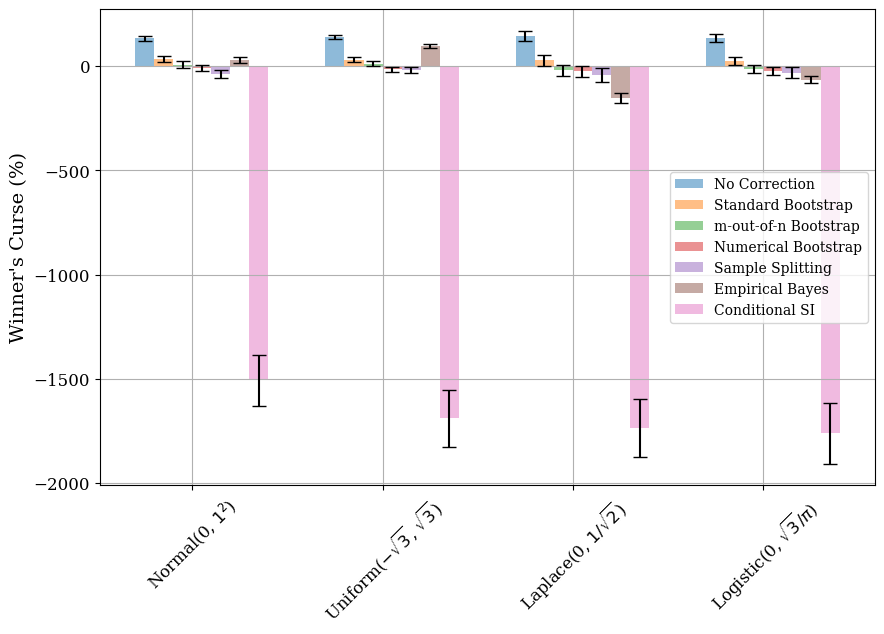

Normal(0, $1^2$)  \
No Correction        Mean              132.96   
                     Median            128.96   
                     S.E.                6.81   
Standard Bootstrap   Mean               34.23   
                     Median             28.98   
                     S.E.                7.59   
m-out-of-n Bootstrap Mean                7.50   
                     Median              4.76   
                     S.E.                7.65   
Numerical Bootstrap  Mean               -9.83   
                     Median            -10.22   
                     S.E.                8.01   
Sample Splitting     Mean              -38.27   
                     Median            -39.16   
                     S.E.                9.81   
Empirical Bayes      Mean               30.81   
                     Median             34.23   
                     S.E.                6.95   
Conditional SI       Mean            -1508.15   
                     Median          -1086.92   
                     S.E.               61.85   

                             Uniform($-\sqrt{3}$, $\sqrt{3}$)  \
No Correction        Mean                              140.29   
                     Median                            139.89   
                     S.E.                                5.34   
Standard Bootstrap   Mean                               31.69   
                     Median                             32.25   
                     S.E.                                6.08   
m-out-of-n Bootstrap Mean                               11.56   
                     Median                             12.83   
                     S.E.                                6.10   
Numerical Bootstrap  Mean                              -15.28   
                     Median                            -13.99   
                     S.E.                                6.54   
Sample Splitting     Mean                              -18.55   
                     Median                            -19.68   
                     S.E.                                8.01   
Empirical Bayes      Mean                               97.29   
                     Median                            100.59   
                     S.E.                                5.34   
Conditional SI       Mean                            -1690.30   
                     Median                          -1146.34   
                     S.E.                               70.69   

                             Laplace(0, $1/\sqrt{2}$)  \
No Correction        Mean                      145.98   
                     Median                    170.82   
                     S.E.                       11.76   
Standard Bootstrap   Mean                       28.05   
                     Median                     35.06   
                     S.E.                       12.83   
m-out-of-n Bootstrap Mean                      -20.57   
                     Median                     -7.63   
                     S.E.                       12.41   
Numerical Bootstrap  Mean                      -23.79   
                     Median                    -25.02   
                     S.E.                       13.60   
Sample Splitting     Mean                      -41.46   
                     Median                     -8.82   
                     S.E.                       16.96   
Empirical Bayes      Mean                     -153.66   
                     Median                   -117.14   
                     S.E.                       11.85   
Conditional SI       Mean                    -1735.85   
                     Median                  -1224.47   
                     S.E.                       71.62   

                             Logistic(0, $\sqrt{3} / \pi$)  
No Correction        Mean                           134.56  
                     Median                         147.64  
                     S.E.                             9.07  
Standard Bootstrap  

In [24]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = cust_feat_var_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for cust_feat_var in cust_feat_var_dict.keys():
    data[cust_feat_var] = {}

    data[cust_feat_var]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[cust_feat_var][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[cust_feat_var][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[cust_feat_var][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[cust_feat_var][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[cust_feat_var][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[cust_feat_var][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[cust_feat_var][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in cust_feat_var_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(cust_feat_var_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(cust_feat_var_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in cust_feat_var_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in cust_feat_var_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(cust_feat_var_dict.keys())), 
    labels=cust_feat_var_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
# plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Max Depth

In [17]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.05)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Bayes (Normal)'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2},
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

max_depth_list = [2, 4, 6, 8, 10]

In [18]:
max_depth_result_dict = {max_depth: None for max_depth in max_depth_list}

for max_depth in max_depth_list:
    print(f'\nMax Depth= {max_depth}')

    experiment_params['estimator']['params']['max_depth'] = max_depth

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    max_depth_result_dict[max_depth] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 2
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 10.3min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 29.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 36.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 11.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 32.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 42.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 13.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 37.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 47.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 8
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 14.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 40.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 51.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 10
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 15.4min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 43.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 54.7min finished


In [19]:
with open('results/targeting_max_depth.pkl', 'wb') as f:
    pickle.dump(max_depth_result_dict, f)

with open('results/targeting_max_depth.pkl', 'rb') as f:
    max_depth_result_dict = pickle.load(f)

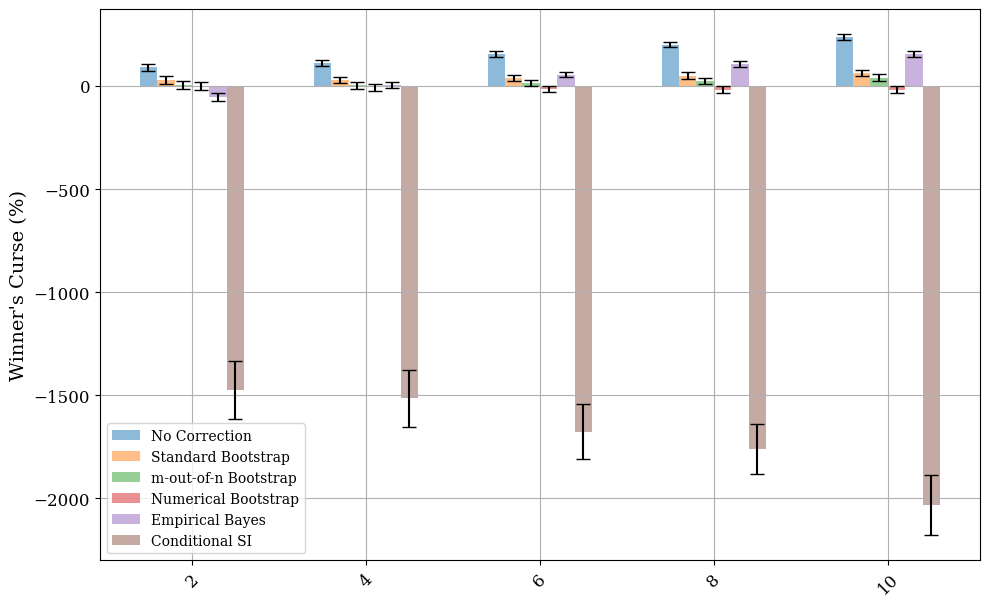

2        4        6        8        10
No Correction        Mean      89.99   111.86   155.42   200.13   237.89
                     Median    88.10   114.60   152.14   199.25   238.61
                     S.E.       9.34     6.94     6.80     6.93     7.07
Standard Bootstrap   Mean      27.57    29.79    39.17    50.27    61.73
                     Median    27.99    28.78    38.36    44.29    61.52
                     S.E.      10.23     7.73     7.54     7.71     7.88
m-out-of-n Bootstrap Mean       5.89     2.76    13.40    25.37    40.98
                     Median     9.45    -6.46    10.00    24.90    32.99
                     S.E.      10.36     7.75     7.59     7.78     8.02
Numerical Bootstrap  Mean      -0.21    -7.18   -13.91   -17.84   -17.83
                     Median    -7.10   -15.63    -7.87   -26.21   -16.74
                     S.E.      10.63     8.13     8.00     8.27     8.28
Empirical Bayes      Mean     -53.11     5.68    55.19   106.75   153.83
                     Median   -44.24     5.60    58.37   107.75   155.07
                     S.E.       9.71     7.07     6.96     7.09     7.23
Conditional SI       Mean   -1474.04 -1515.27 -1677.90 -1761.08 -2032.67
                     Median  -994.56 -1026.22 -1205.79 -1366.17 -1528.46
                     S.E.      71.36    71.07    68.01    62.40    74.38

In [20]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = max_depth_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for max_depth in max_depth_list:
    data[max_depth] = {}

    data[max_depth]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[max_depth][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[max_depth][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for max_depth in max_depth_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[max_depth][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=max_depth_list
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(max_depth_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in max_depth_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in max_depth_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(max_depth_list)), 
    labels=max_depth_list, 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [21]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = max_depth_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for max_depth in max_depth_list:
    data[max_depth] = {}

    wc_mean = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[max_depth]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[max_depth][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)[[2, 4, 6, 8, 10]]
latex_df.columns = [f'Depth={max_depth}' for max_depth in [2, 4, 6, 8, 10]]
print(latex_df.style.to_latex(
    column_format='c' * (len([2, 4, 6, 8, 10]) + 1), 
    hrules=True
))

\begin{tabular}{cccccc}
\toprule
 & Depth=2 & Depth=4 & Depth=6 & Depth=8 & Depth=10 \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$89.99\%^{***}$\\ ($9.34\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$111.86\%^{***}$\\ ($6.94\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$155.42\%^{***}$\\ ($6.80\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$200.13\%^{***}$\\ ($6.93\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$237.89\%^{***}$\\ ($7.07\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$27.57\%^{***}$\\ ($10.23\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$29.79\%^{***}$\\ ($7.73\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$39.17\%^{***}$\\ ($7.54\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$50.27\%^{***}$\\ ($7.71\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$61.73\%^{***}$\\ ($7.88\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$5.89\%$\\ ($10.36\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$2.76\%$\\ ($7.75\%$)\end{tabular}

In [162]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1 + i * 0.05) for i in range(2)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': None, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': None, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {}

max_depth_list = [2, 4, 6, 8, 10, 15, 20, 25, 30]
depth_sample_size_list = [1000, 5000, 10000, 15000, 20000]

In [13]:
depth_sample_size_result_dict = {(sample_size, max_depth): None for sample_size in depth_sample_size_list for max_depth in max_depth_list}

for sample_size in depth_sample_size_list:
    for max_depth in max_depth_list:
        print(f'\nSample Size= {sample_size}, Max Depth= {max_depth}')

        experiment_params['estimator']['params']['max_depth'] = max_depth
        data_params['sample_size'] = sample_size

        result_records = repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params,
            estimators_dict=estimators_dict,
            verbose=False,
            n_jobs=-1
        )

        depth_sample_size_result_dict[(sample_size, max_depth)] = calculate_winners_curse_measures(
            result_records=result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params
        )


Sample Size= 1000, Max Depth= 2

Sample Size= 1000, Max Depth= 4

Sample Size= 1000, Max Depth= 6

Sample Size= 1000, Max Depth= 8

Sample Size= 1000, Max Depth= 10

Sample Size= 1000, Max Depth= 15

Sample Size= 1000, Max Depth= 20

Sample Size= 1000, Max Depth= 25

Sample Size= 1000, Max Depth= 30

Sample Size= 5000, Max Depth= 2

Sample Size= 5000, Max Depth= 4

Sample Size= 5000, Max Depth= 6

Sample Size= 5000, Max Depth= 8

Sample Size= 5000, Max Depth= 10

Sample Size= 5000, Max Depth= 15

Sample Size= 5000, Max Depth= 20

Sample Size= 5000, Max Depth= 25

Sample Size= 5000, Max Depth= 30

Sample Size= 10000, Max Depth= 2

Sample Size= 10000, Max Depth= 4

Sample Size= 10000, Max Depth= 6

Sample Size= 10000, Max Depth= 8

Sample Size= 10000, Max Depth= 10

Sample Size= 10000, Max Depth= 15

Sample Size= 10000, Max Depth= 20


A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Sample Size= 10000, Max Depth= 25

Sample Size= 10000, Max Depth= 30

Sample Size= 15000, Max Depth= 2

Sample Size= 15000, Max Depth= 4

Sample Size= 15000, Max Depth= 6

Sample Size= 15000, Max Depth= 8

Sample Size= 15000, Max Depth= 10

Sample Size= 15000, Max Depth= 15

Sample Size= 15000, Max Depth= 20

Sample Size= 15000, Max Depth= 25

Sample Size= 15000, Max Depth= 30

Sample Size= 20000, Max Depth= 2

Sample Size= 20000, Max Depth= 4

Sample Size= 20000, Max Depth= 6

Sample Size= 20000, Max Depth= 8

Sample Size= 20000, Max Depth= 10

Sample Size= 20000, Max Depth= 15

Sample Size= 20000, Max Depth= 20

Sample Size= 20000, Max Depth= 25

Sample Size= 20000, Max Depth= 30


In [160]:
# with open('results/targeting_depth_sample_size.pkl', 'wb') as f:
#     pickle.dump(depth_sample_size_result_dict, f)

with open('results/targeting_depth_sample_size.pkl', 'rb') as f:
    depth_sample_size_result_dict = pickle.load(f)

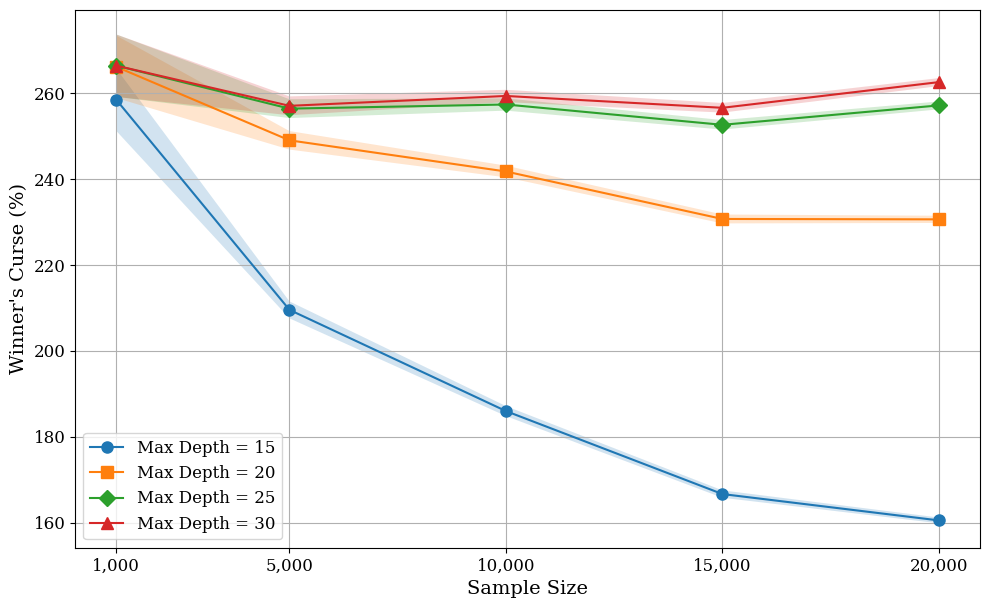

In [172]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

markers = ['o', 's', 'D', '^']

viz_max_depth_list = [15, 20, 25, 30]
for i, max_depth in enumerate(viz_max_depth_list):
    wc_avg_list = [result_dict['rank_and_select_nc_wc_avg'] * 100 / delta_tau for (_, depth), result_dict in depth_sample_size_result_dict.items() if depth == max_depth]
    wc_se_list = [result_dict['rank_and_select_nc_wc_se'] * 100 / delta_tau for (_, depth), result_dict in depth_sample_size_result_dict.items() if depth == max_depth]

    ax.plot(
        depth_sample_size_list, wc_avg_list, 
        label=f'Max Depth = {max_depth}', 
        marker=markers[i], 
        markersize=8
    )
    ax.fill_between(
        depth_sample_size_list, 
        np.array(wc_avg_list) - 1.96 * np.array(wc_se_list), 
        np.array(wc_avg_list) + 1.96 * np.array(wc_se_list), 
        alpha=0.2
    )

ax.set_xlabel('Sample Size', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(depth_sample_size_list, labels=[f'{s_:,}' for s_ in depth_sample_size_list])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.grid()
plt.tight_layout()
plt.savefig('figures/targeting_depth_sample_size.jpg')
plt.show()

# Bernoulli Response

In [67]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(0.1), PointMass(0.11)], 
    'cust_feat_var': Uniform(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': LogisticRegression(C=0.01), 
            'n_estimators': 500, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_outcome': True, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5}, 
        'display_name': 'Sample Splitting', 
    }, 
    # 'standard_bootstrap': {
    #     'estimator': bootstrap_correction_estimate, 
    #     'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
    #     'display_name': 'Standard Bootstrap'
    # },
    # 'mn_bootstrap': {
    #     'estimator': bootstrap_correction_estimate, 
    #     'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
    #     'display_name': 'm-out-of-n Bootstrap'
    # },
    # 'num_bootstrap': {
    #     'estimator': bootstrap_correction_estimate, 
    #     'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
    #     'display_name': 'Numerical Bootstrap'
    # }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Bayes'
    # }, 
    # 'eb_normal': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
    #     'display_name': 'Empirical Bayes'
    # }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'conditional_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Conditional SI'
    # }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

In [ ]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
The least populated class in y has only 1 members, which is less than n_splits=2.
The least populated class in y has only 1 members, which is less than n_splits=2.
invalid value encountered in sqrt
The least populated class in y has only 1 members, which is less than n_splits=2.
The least populated class in y has only 1 members, which is less than n_splits=2.
The least populated class in y has only 1 members, which is less than n_splits=2.
The least populated class in y has only 1 members, which is less than n_splits=2.
The least populated class in y has only 1 members, which is less than n_splits=2.



Selection with Rank and Select:
Policy Value: 
  - True Value: 0.1710 (0.0012)
  - No Correction: 0.2166 (0.0037)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: 456.85% (35.03%)
Median Winner's Curse: 
  - No Correction: 461.11% (35.03%)

Sample Splitting: 
  - True Value: 0.1711 (0.0012)
  - Estimated Value: 0.1709 (0.0050)
  - Winner's Curse (%): -2.36% (49.79%)


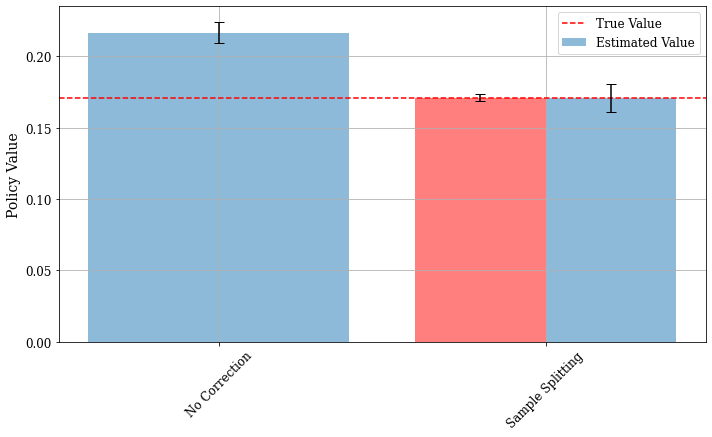

In [ ]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

optimizer_key = 'rank_and_select'

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()], 
        rotation=45, 
        fontsize=tick_label_size
    )
# ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


# Sketch

In [32]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': Uniform(-1, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 10000} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 1000, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

In [102]:
# sample 
# seed = 3
seed = 0

dgp = Targeting(**dgp_params)

cust_features, treatments, outcomes = dgp.sample(data_params['sample_size'], seed)
oos_cust_features = dgp.sample_individuals(data_params['targ_sample_size'], seed + 10000)
oos_cust_features = np.sort(oos_cust_features, axis=0)
# oos_cust_features = np.linspace(-1, 1, 1000)[:, None]

In [103]:
# split the data 
np.random.seed(seed)

estimation_split = 0.5 
sample_size = cust_features.shape[0]
est_size = int(sample_size * estimation_split)
est_indices = np.random.choice(sample_size, size=est_size, replace=False)
eval_indices = np.setdiff1d(np.arange(sample_size), est_indices)

# Training data for estimation and evaluation
est_features = cust_features[est_indices]
est_treatments = treatments[est_indices]
est_outcomes = outcomes[est_indices]

eval_features = cust_features[eval_indices]
eval_treatments = treatments[eval_indices]
eval_outcomes = outcomes[eval_indices]

In [104]:
# fit two models 
model = experiment_params['estimator']['estimator']
model_params = experiment_params['estimator']['params']

est_model = model(**model_params).fit(X=est_features, Y=est_outcomes, T=est_treatments)
full_model = model(**model_params).fit(X=cust_features, Y=outcomes, T=treatments)

In [105]:
# optimzie for the policy
full_selection, _ = optimize(
    demand_model=full_model, cust_features=oos_cust_features,
)
half_selection, _ = optimize(
    demand_model=est_model, cust_features=oos_cust_features,
)

# policy values
full_val_true = obj_func(
    full_selection, cust_feautres=oos_cust_features, demand_model=dgp, 
)
half_val_true = obj_func(
    half_selection, cust_feautres=oos_cust_features, demand_model=dgp, 
)

print(f'True Policy Value: ')
print(f' - Full Dataset: {full_val_true:.4f}')
print(f' - Half Dataset: {half_val_true:.4f}')

True Policy Value: 
 - Full Dataset: 0.3536
 - Half Dataset: 0.3279


Average variance of the estimated lift: 
 - Full Dataset: 0.0262
 - Half Dataset: 0.0701


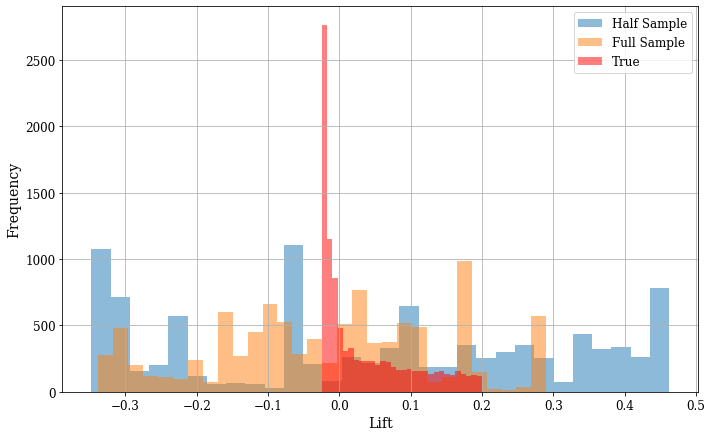

In [106]:
# get the treatment effect estimates
est_pred, _ = est_model.predict_incremental_effect(oos_cust_features)
full_pred, _ = full_model.predict_incremental_effect(oos_cust_features)
true_pred, _ = dgp.predict_incremental_effect(oos_cust_features)

# calculate lift
true_lift = true_pred[:, 1] - true_pred[:, 0]
est_lift = est_pred[:, 1] - est_pred[:, 0]
full_lift = full_pred[:, 1] - full_pred[:, 0]

print(f'Average variance of the estimated lift: ')
print(f' - Full Dataset: {np.var(full_lift):.4f}')
print(f' - Half Dataset: {np.var(est_lift):.4f}')

# plot the histogram of lift
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.hist(est_lift, bins=30, alpha=0.5, label='Half Sample', color='C0')
ax.hist(full_lift, bins=30, alpha=0.5, label='Full Sample', color='C1')
ax.hist(true_lift, bins=30, alpha=0.5, label='True', color='red')

ax.set_xlabel('Lift', fontsize=axis_label_size)
ax.set_ylabel('Frequency', fontsize=axis_label_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

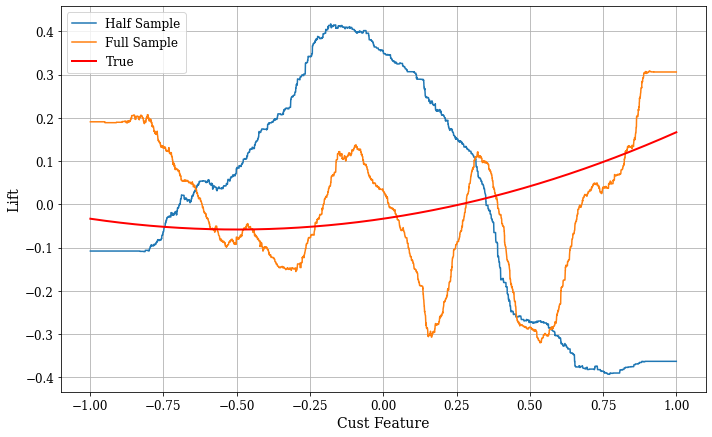

In [107]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.plot(oos_cust_features, est_lift - est_lift.mean(), label='Half Sample', color='C0')
ax.plot(oos_cust_features, full_lift - full_lift.mean(), label='Full Sample', color='C1')
ax.plot(oos_cust_features, true_lift - true_lift.mean(), label='True', color='red', linewidth=2)

ax.set_xlabel('Cust Feature', fontsize=axis_label_size)
ax.set_ylabel('Lift', fontsize=axis_label_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

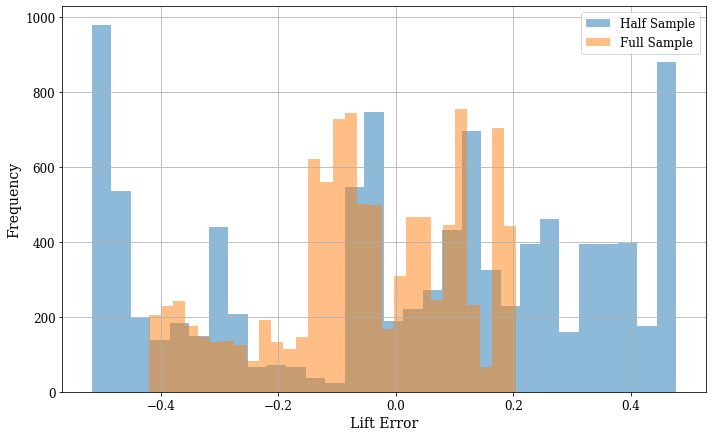

,Half,Full
mean,0.012009,-0.051416
std,0.317074,0.162891
skew,-0.284731,-0.443798
kurt,-1.193234,-0.520219


In [108]:
half_error = est_lift - true_lift
full_error = full_lift - true_lift

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))
ax.hist(half_error, bins=30, alpha=0.5, label='Half Sample', color='C0')
ax.hist(full_error, bins=30, alpha=0.5, label='Full Sample', color='C1')

ax.set_xlabel('Lift Error', fontsize=axis_label_size)
ax.set_ylabel('Frequency', fontsize=axis_label_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()

pd.DataFrame({
    'Half': {'mean': half_error.mean(), 'std': half_error.std(), 'skew': skew(half_error), 'kurt': kurtosis(half_error)},
    'Full': {'mean': full_error.mean(), 'std': full_error.std(), 'skew': skew(full_error), 'kurt': kurtosis(full_error)}
})

In [114]:
dgp = Targeting(**dgp_params)

def single_experiment(seed): 
    cust_features, treatments, outcomes = dgp.sample(data_params['sample_size'], seed)
    oos_cust_features = dgp.sample_individuals(data_params['targ_sample_size'], seed + 10000)

    estimation_split = 0.5 
    sample_size = cust_features.shape[0]
    est_size = int(sample_size * estimation_split)
    est_indices = np.random.choice(sample_size, size=est_size, replace=False)
    eval_indices = np.setdiff1d(np.arange(sample_size), est_indices)

    # Training data for estimation and evaluation
    est_features = cust_features[est_indices]
    est_treatments = treatments[est_indices]
    est_outcomes = outcomes[est_indices]

    # eval_features = cust_features[eval_indices]
    # eval_treatments = treatments[eval_indices]
    # eval_outcomes = outcomes[eval_indices]

    # fit two models 
    model = experiment_params['estimator']['estimator']
    model_params = experiment_params['estimator']['params']

    est_model = model(**model_params).fit(X=est_features, Y=est_outcomes, T=est_treatments)
    full_model = model(**model_params).fit(X=cust_features, Y=outcomes, T=treatments)

    # optimzie for the policy
    full_selection, _ = optimize(
        demand_model=full_model, cust_features=oos_cust_features,
    )
    half_selection, _ = optimize(
        demand_model=est_model, cust_features=oos_cust_features,
    )

    # policy values
    full_val_true = obj_func(
        full_selection, cust_feautres=oos_cust_features, demand_model=dgp, 
    )
    half_val_true = obj_func(
        half_selection, cust_feautres=oos_cust_features, demand_model=dgp, 
    )

    # get the treatment effect estimates
    est_pred, _ = est_model.predict_incremental_effect(oos_cust_features)
    full_pred, _ = full_model.predict_incremental_effect(oos_cust_features)
    true_pred, _ = dgp.predict_incremental_effect(oos_cust_features)

    # calculate lift
    true_lift = true_pred[:, 1] - true_pred[:, 0]
    est_lift = est_pred[:, 1] - est_pred[:, 0]
    full_lift = full_pred[:, 1] - full_pred[:, 0]

    half_error = est_lift - true_lift
    full_error = full_lift - true_lift

    return {
        'full_val_true': full_val_true,
        'half_val_true': half_val_true,
        'full_lift': full_lift,
        'half_lift': est_lift,
        'full_error': full_error,
        'half_error': half_error,
    }

records = Parallel(n_jobs=-1, verbose=True)(
    delayed(single_experiment)(seed) for seed in range(500)
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   46.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  9.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 10.9min finished


In [120]:
ss_is_better_records = [record for record in records if record['full_val_true'] < record['half_val_true']]
ss_is_worse_records = [record for record in records if record['full_val_true'] > record['half_val_true']]

print(f'Number of times sample splitting is better: {len(ss_is_better_records)}')
print(f'Number of times sample splitting is worse: {len(ss_is_worse_records)}')

Number of times sample splitting is better: 267
Number of times sample splitting is worse: 229


In [118]:
ss_is_better_stats = pd.DataFrame({
    'Full': {
        'Error Mean': np.mean([record['full_error'].mean() for record in ss_is_better_records]),
        'Error Vol': np.mean([record['full_error'].std() for record in ss_is_better_records]),
        'Error Skew': np.mean([skew(record['full_error']) for record in ss_is_better_records]),
        'Error Kurt': np.mean([kurtosis(record['full_error']) for record in ss_is_better_records]),
        'Policy Value': np.mean([record['full_val_true'] for record in ss_is_better_records]),
    }, 
    'Half': {
        'Error Mean': np.mean([record['half_error'].mean() for record in ss_is_better_records]),
        'Error Vol': np.mean([record['half_error'].std() for record in ss_is_better_records]),
        'Error Skew': np.mean([skew(record['half_error']) for record in ss_is_better_records]),
        'Error Kurt': np.mean([kurtosis(record['half_error']) for record in ss_is_better_records]),
        'Policy Value': np.mean([record['half_val_true'] for record in ss_is_better_records]),
    }
})
ss_is_better_stats

,Full,Half
Error Mean,0.006069,0.030515
Error Vol,0.294295,0.275037
Error Skew,-0.008727,-0.035585
Error Kurt,-0.596017,-0.947355
Policy Value,0.354538,0.364025


In [119]:
ss_is_worse_stats = pd.DataFrame({
    'Full': {
        'Error Mean': np.mean([record['full_error'].mean() for record in ss_is_worse_records]),
        'Error Vol': np.mean([record['full_error'].std() for record in ss_is_worse_records]),
        'Error Skew': np.mean([skew(record['full_error']) for record in ss_is_worse_records]),
        'Error Kurt': np.mean([kurtosis(record['full_error']) for record in ss_is_worse_records]),
        'Policy Value': np.mean([record['full_val_true'] for record in ss_is_worse_records]),
    }, 
    'Half': {
        'Error Mean': np.mean([record['half_error'].mean() for record in ss_is_worse_records]),
        'Error Vol': np.mean([record['half_error'].std() for record in ss_is_worse_records]),
        'Error Skew': np.mean([skew(record['half_error']) for record in ss_is_worse_records]),
        'Error Kurt': np.mean([kurtosis(record['half_error']) for record in ss_is_worse_records]),
        'Policy Value': np.mean([record['half_val_true'] for record in ss_is_worse_records]),
    }
})
ss_is_worse_stats

,Full,Half
Error Mean,-0.009231,-0.046071
Error Vol,0.287917,0.282322
Error Skew,-0.084829,-0.019188
Error Kurt,-0.420961,-0.917715
Policy Value,0.355728,0.344702


In [123]:
all_stats = pd.DataFrame({
    'Full': {
        'Error Mean': np.mean([record['full_error'].mean() for record in records]),
        'Error Vol': np.mean([record['full_error'].std() for record in records]),
        'Error Skew': np.mean([skew(record['full_error']) for record in records]),
        'Error Kurt': np.mean([kurtosis(record['full_error']) for record in records]),
    }, 
    'Half': {
        'Error Mean': np.mean([record['half_error'].mean() for record in records]),
        'Error Vol': np.mean([record['half_error'].std() for record in records]),
        'Error Skew': np.mean([skew(record['half_error']) for record in records]),
        'Error Kurt': np.mean([kurtosis(record['half_error']) for record in records]),
    }
})
all_stats

,Full,Half
Error Mean,0.001255,-0.001980
Error Vol,0.290926,0.277418
Error Skew,-0.038082,-0.029871
Error Kurt,-0.509900,-0.930504
